In [1]:
from pathlib import Path
import os
import os.path as op
import numpy as np
import pandas as pd
import pickle
import itertools as it
 
from joblib import Parallel, delayed
 
import scipy.integrate
# Fix for kcsd-python compatibility with SciPy >= 1.14
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson
from kcsd import KCSD1D
 
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from matplotlib.patches import Patch

from scipy.interpolate import interp1d
import io
import sys
from tqdm import tqdm

In [2]:
def check_many(multiple, target, func=None):
    func_dict = {
        "all": all, "any": any
    }
    if func in func_dict:
        use_func = func_dict[func]
    else:
        raise ValueError("pick function 'all' or 'any'")
    check_ = []
    for i in multiple:
        check_.append(i in target)
    return use_func(check_)

def get_files(target_path, suffix, strings=(""), prefix=None, check="all", depth="all"):
    path = Path(target_path)
    files = []
    if depth == "all":
        files = [file for file in path.rglob(suffix)
                 if file.is_file() and file.suffix == suffix[1:] and
                 check_many(strings, file.name, check)]
    elif depth == "one":
        files = [file for file in path.iterdir()
                 if file.is_file() and file.suffix == suffix[1:] and
                 check_many(strings, file.name, check)]

    if isinstance(prefix, str):
        files = [file for file in files if file.name.startswith(prefix)]
    files.sort(key=lambda x: x.name)
    return files

In [3]:
plt.rcParams.update({
    'font.size': 16,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})
 
def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

Load the data

In [4]:
res_dir = Path("./sim_err/")
res_files = get_files(res_dir, "*.pickle")
 
res = []
for f in res_files:
    with open(f, "rb") as file:
        data = pickle.load(file)
    res.append(data)
df = pd.DataFrame(res)
 
# Merge quartile info
verts_q = pd.read_csv('verts_per_anat_q.csv')
cols_to_retreive = ["vertex", "thickness_q", "lf_rms_diff_q", "orientations_q", "dist_to_scalp_q"]
df = df.merge(
    verts_q[cols_to_retreive],
    left_on="sim_vertex",
    right_on="vertex",
    how="left"
).drop(columns="vertex")
 
n_layers = 11
sim_layers = np.arange(n_layers)
time = df['time'][0]
zero_time_idx = int((len(time) - 1) / 2 + 1)

In [5]:
with open('optimal_params.pickle', 'rb') as f:
        optimal_params = pickle.load(f)

Compute relative free energy  (shape: n_rows × 11 × 11)

In [6]:
fs_matrix = np.stack(df['fs'].to_numpy(), axis=0)          # (n_rows, 11, 11)
relativeFs = np.stack([
    np.array([
        fs_matrix[r, sim_layer, :] - fs_matrix[r, sim_layer, :].min()
        for sim_layer in range(fs_matrix.shape[1])
    ])
    for r in range(fs_matrix.shape[0])
], axis=0)
df['rfs'] = list(relativeFs)

Compute kcsd (shape: n_rows × 11 × 100) with DNR adaptive optimal R/ lambda selection 

Without optimization peaks collapse to the boundary
- high lambda: over-smoothed so boundary electrodes will capture the most variance because kcsd1D zero-boundary conditions pull mass outward
- large R - basis functions cover the whole column; spatial specificity is lost and the inversion defaults to broad exterior sources
- raw amplitude peak works better because it skips the inversion entirely - but wouldn't work in real data where we always have decreasing amplitude signal with depth 

Strategy to counter that? Usually kcsd is optimizing by itself the tradeoff between R and lambas, but not per SNR level
- sample n_calib rows vertices per snr as calibration set
- for each (R, lambda) pair run leave-one-electrode-out CV on every calibration row and sim-layer; average the reconstruction error
3. Pick the (R* lambda*) minimising that mean CV error
- Re-run kcsd on all rows for that snr with the fixed optimal params

Note that R is a fraction of cortical thickness so it scales across vertices, lambda is explored log-spaced from near-zero to large

In [7]:
def norm_res_col(mx):
    """
    Normalise each *simulation* column so its minimum is 0.
    Input shape: (n_sim_layers, n_eval_points)   [Code-2 convention]
    Mirrors Code-1 norm_res which normalises each column of (eval, sim).
    """
    normed = np.zeros_like(mx)
    for sim_l in range(mx.shape[0]):
        col = mx[sim_l, :]
        normed[sim_l, :] = col - col.min()
    return normed
 
 
def find_peaks_col(mx, marker="*", return_annot=True):
    """
    For each simulation layer (row in Code-2 convention), find the evaluation
    point with the maximum value.
 
    mx shape: (n_sim_layers, n_eval_points)
 
    Returns
    -------
    peaks      : (n_sim_layers,) index of argmax in eval dimension
    annot      : object array with marker at peak positions (for imshow)
    annot_bin  : float array with 1.0 at peak positions
    """
    n_sim, n_eval = mx.shape
    annot = np.zeros((n_sim, n_eval), dtype=object)
    peaks = []
    for sim_l in range(n_sim):
        peak = np.argmax(mx[sim_l, :])
        annot[sim_l, peak] = 1.0
        peaks.append(peak)
    peaks = np.array(peaks)
    annot_bin = annot.astype(float)
    annot_obj = np.where(annot_bin == 1.0, marker, None)
    if return_annot:
        return peaks, annot_obj, annot_bin
    else:
        return peaks
 
 
def shuffle_mx(mx):
    flat = mx.flatten()
    np.random.shuffle(flat)
    return flat.reshape(mx.shape)
 
 
def shuffled_peak_error(mx, ab=False):
    """Compute peak error on a shuffled copy of mx."""
    mx_sh = shuffle_mx(mx)
    peaks = find_peaks_col(mx_sh, return_annot=False)
    # For Code-2 convention the 'true' layer index equals the row index
    n_sim = mx.shape[0]
    # Map peaks from eval-space to layer-space when eval != n_layers
    if mx.shape[1] != n_layers:
        peaks_mapped = peaks / mx.shape[1] * (n_layers - 1)
    else:
        peaks_mapped = peaks.astype(float)
    errors = peaks_mapped - np.arange(n_sim)
    return errors if not ab else np.abs(errors)
 
 
def bootstrap(data, n_boot=1000, prop=0.5):
    n_rows = data.shape[0]
    prop_rows = int(n_rows * prop)
    rows = np.arange(n_rows)
    results = [data[np.random.choice(rows, size=prop_rows)] for _ in range(n_boot)]
    return np.array(results)
 
 
def diagonal_dominance_score(matrix):
    """Fraction of total weight on the diagonal (Code-1 metric)."""
    return np.trace(matrix) / np.sum(matrix)

In [22]:
OUTPUT_SIZE = 11

def compute_kcsd_vectorized(row, zero_time_idx, R_mm=None, lam=None):
    """
    Compute kCSD for all layers of one row using fixed params.
    kCSD1D expects (n_ch, 1) electrodes and (n_ch, n_times) potentials,
    returning (n_est, n_times) CSD estimates. We loop over layers.
    """
    # Scipy patch inside worker (loky doesn't run a pool initializer)
    import scipy.integrate
    if not hasattr(scipy.integrate, 'simps'):        
        scipy.integrate.simps = scipy.integrate.simpson
    from kcsd import KCSD1D                          

    ts_full   = row['ts']
    thickness = row['thickness']
    n_layers  = ts_full.shape[0]
    n_ch      = ts_full.shape[1]

    x_elec = np.linspace(0, thickness, n_ch).reshape(-1, 1)
    gdx    = thickness / (OUTPUT_SIZE - 1)

    results = []

    # Loop over layers (~11 iterations, unavoidable given kCSD1D's 1D interface)
    for layer_idx in range(n_layers):                
        t_start = zero_time_idx - 5
        t_end   = min(zero_time_idx + 5, ts_full.shape[2])  
        pot_win = ts_full[layer_idx, :, t_start:t_end]      # shape (n_ch, n_times_window)

        kc = KCSD1D(
            x_elec, 
            pot_win, 
            xmin=0.0, 
            xmax=float(thickness),
            gdx=gdx)

        
        if R_mm is not None:
            if lam is not None:
                kc.cross_validate(lambdas=lam, Rs=R_mm)
            else: 
                kc.cross_validate(Rs=R_mm)             

        csd = kc.values('CSD')                       

        if csd.shape[0] != OUTPUT_SIZE:              
            x_old = np.linspace(0, 1, csd.shape[0]) 
            x_new = np.linspace(0, 1, OUTPUT_SIZE)
            csd   = interp1d(x_old, csd, axis=0)(x_new)

        results.append(csd)                          # shape: (n_est, n_times)

    # Stack layers -> (n_layers, n_est, n_times)
    return np.stack(results)


# --- Parallel execution over all rows ----------------------------------------

kcsd_results = Parallel(n_jobs=32, backend='loky', verbose=10)(
    delayed(compute_kcsd_vectorized)(
        row,
        zero_time_idx,
        #R_mm = np.array([0.1, 0.2, 0.5, 1, 2, 4, 8])
        #R_mm=optimal_params[row['snr']]['mean error']['R_frac'] * row['thickness'],
        #lam=optimal_params[row['snr']]['mean error']['lambda'],
    )
    for _, row in df.iterrows()                      
)

[Parallel(n_jobs=32)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done   8 tasks      | elapsed:    1.8s
[Parallel(n_jobs=32)]: Done  21 tasks      | elapsed:    1.8s
[Parallel(n_jobs=32)]: Done  34 tasks      | elapsed:    2.0s
[Parallel(n_jobs=32)]: Done  49 tasks      | elapsed:    2.0s
[Parallel(n_jobs=32)]: Done  64 tasks      | elapsed:    2.1s
[Parallel(n_jobs=32)]: Done  81 tasks      | elapsed:    2.2s
[Parallel(n_jobs=32)]: Done  98 tasks      | elapsed:    2.3s
[Parallel(n_jobs=32)]: Done 117 tasks      | elapsed:    2.3s
[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    2.4s
[Parallel(n_jobs=32)]: Done 157 tasks      | elapsed:    2.5s
[Parallel(n_jobs=32)]: Done 178 tasks      | elapsed:    2.6s
[Parallel(n_jobs=32)]: Done 201 tasks      | elapsed:    2.7s
[Parallel(n_jobs=32)]: Done 224 tasks      | elapsed:    2.8s
[Parallel(n_jobs=32)]: Done 249 tasks      | elapsed:    2.9s
[Parallel(n_jobs=32)]: Done 274 tasks      | elapsed:  

In [23]:
kcsd = np.array(kcsd_results)
kcsd_m = np.mean(kcsd, axis=3)
df['kcsd'] = list(kcsd_m)

Build method matrices & per-row stats

In [24]:
def norm_res_max(mx):
    """Min-max normalise each row to [0, 1] along the last axis."""
    mn  = np.min(mx, axis=-1, keepdims=True)
    mx_ = np.max(mx, axis=-1, keepdims=True)
    denom = mx_ - mn
    denom = np.where(denom == 0, 1, denom)   # avoid division by zero for flat rows
    return (mx - mn) / denom
 
ts_arr   = np.stack(df['ts'].to_numpy(), axis=0)
ts_t0    = np.mean(ts_arr[..., zero_time_idx-5:zero_time_idx+5], axis=-1)
norm_ts_t0   = norm_res_max(ts_t0)
norm_kcsd_m  = norm_res_max(kcsd_m)
 
# methods dict: name -> (n_rows, n_sim_layers, n_eval_points)
methods_dict = {
    'rfs':      relativeFs,    # (n_rows, 11, 11)
    'kcsd':     kcsd_m,        # (n_rows, 11, 100)
    'norm_kcsd': norm_kcsd_m,  # (n_rows, 11, 100)
    'ts':       ts_t0,         # (n_rows, 11, n_ch)
    'norm_ts':  norm_ts_t0,    # (n_rows, 11, n_ch)
}
 
meta_cols = ["sim_vertex", "err_level",
             "thickness_q", "lf_rms_diff_q", "orientations_q", "dist_to_scalp_q"]
 
rows_list = []
for method_name, matrix_3d in methods_dict.items():
    n_eval = matrix_3d.shape[2]
    for row_idx in range(matrix_3d.shape[0]):
        mx = matrix_3d[row_idx]                      # (11, n_eval)
        mx_norm = norm_res_col(mx)                   # normalise each sim-layer column
 
        peaks = find_peaks_col(mx_norm, return_annot=False)   # (11,)
 
        # Map peak indices to layer space if eval resolution differs
        if n_eval != n_layers:
            peaks_mapped = peaks / n_eval * (n_layers - 1)
        else:
            peaks_mapped = peaks.astype(float)
 
        error = np.abs(sim_layers - peaks_mapped)    # (11,)  per-layer absolute error
        bias  = sim_layers.astype(float) - peaks_mapped  # (11,)  per-layer signed error
 
        row_meta = {col: df.loc[row_idx, col] for col in meta_cols}
        rows_list.append({
            'method':       method_name,
            'norm_matrix':  mx_norm,
            'raw_matrix':   mx,
            **row_meta,
            'peaks':        peaks_mapped,
            'error':        error,          # (11,) – matches Code-1 layout
            'bias':         bias,           # (11,) – matches Code-1 layout
            'error_m':      np.mean(error),
            'bias_m':       np.mean(bias),
            'error_sd':     np.std(error),
            'bias_sd':      np.std(bias),
        })
 
res_df = pd.DataFrame(rows_list)
 
err_level_range = np.sort(res_df.err_level.unique())
methods   = res_df.method.unique()

Permutation testing (from code multilaminar paper)

In [25]:
n_permutations = 10000
 
# Storage keyed by method
stats = {m: {} for m in methods}
 
for method in methods:
    error_lines   = []
    bias_lines    = []
    error_res     = []
    bias_res      = []
    shuf_error_res = []
    shuf_bias_res  = []
    p_values_error = []
    p_values_bias  = []
    effect_sizes_error = []
    effect_sizes_bias  = []
 
    for err in err_level_range:
        subset = res_df[(res_df.method == method) & (res_df.err_level == err)]
 
        matrices = subset['norm_matrix'].tolist()
        error    = np.array(subset['error'].tolist())   # (n_vx, 11)
        bias     = np.array(subset['bias'].tolist())    # (n_vx, 11)
 
        # Average across simulation layers → one value per vertex
        error_mean = np.mean(error, axis=-1)   # (n_vx,)
        bias_mean  = np.mean(bias,  axis=-1)   # (n_vx,)
 
        # Bootstrap 95 % CIs of the vertex-level means
        error_bs = np.mean(bootstrap(error_mean, n_boot=5000), axis=1)
        bias_bs  = np.mean(bootstrap(bias_mean,  n_boot=5000), axis=1)
 
        # Permutation null distribution
        perm_error = np.zeros(n_permutations)
        perm_bias  = np.zeros(n_permutations)
        for idx in range(n_permutations):
            rand_mx = matrices[np.random.randint(len(matrices))]
            perm_error[idx] = np.mean(shuffled_peak_error(rand_mx, ab=True))
            perm_bias[idx]  = np.mean(shuffled_peak_error(rand_mx, ab=False))
 
        # p-values  (same formulation as Code-1)
        p_err  = (np.sum(perm_error < np.mean(error_mean)) + 1) / (n_permutations + 1)
        p_bias = (np.sum(
            np.abs(perm_bias - np.mean(perm_bias)) >=
            np.abs(np.mean(bias_mean) - np.mean(perm_bias))
        ) + 1) / (n_permutations + 1)
 
        # Cohen's d
        d_err  = (np.mean(error_mean) - np.mean(perm_error)) / np.std(perm_error,  ddof=1)
        d_bias = (np.mean(bias_mean)  - np.mean(perm_bias))  / np.std(perm_bias,   ddof=1)
 
        # 95 % CIs
        e_ci   = [np.percentile(error_bs,  2.5), np.percentile(error_bs,  97.5)]
        e_ci_s = [np.percentile(perm_error, 2.5), np.percentile(perm_error, 97.5)]
        b_ci   = [np.percentile(bias_bs,   2.5), np.percentile(bias_bs,   97.5)]
        b_ci_s = [np.percentile(perm_bias,  2.5), np.percentile(perm_bias,  97.5)]
 
        error_lines.append(error_mean)
        bias_lines.append(bias_mean)
        error_res.append([np.mean(error_mean)] + e_ci)
        bias_res.append([np.mean(bias_mean)]   + b_ci)
        shuf_error_res.append([np.mean(perm_error)] + e_ci_s)
        shuf_bias_res.append([np.mean(perm_bias)]   + b_ci_s)
        p_values_error.append(p_err)
        p_values_bias.append(p_bias)
        effect_sizes_error.append(d_err)
        effect_sizes_bias.append(d_bias)
 
        print(f'[{method}] {err} dB | '
              f'error: d={d_err:.2f}, p={p_err:.3f} | '
              f'bias:  d={d_bias:.2f}, p={p_bias:.3f}')
 
    stats[method] = dict(
        error_lines   = np.array(error_lines),
        bias_lines    = np.array(bias_lines),
        error_res     = np.array(error_res),
        bias_res      = np.array(bias_res),
        shuf_error_res = np.array(shuf_error_res),
        shuf_bias_res  = np.array(shuf_bias_res),
        p_values_error = np.array(p_values_error),
        p_values_bias  = np.array(p_values_bias),
        effect_sizes_error = np.array(effect_sizes_error),
        effect_sizes_bias  = np.array(effect_sizes_bias),
    )

[rfs] 0.5 dB | error: d=-4.47, p=0.000 | bias:  d=0.03, p=1.000
[rfs] 1.0 dB | error: d=-3.89, p=0.000 | bias:  d=0.01, p=0.963
[rfs] 2.0 dB | error: d=-2.89, p=0.001 | bias:  d=0.04, p=0.961
[rfs] 3.0 dB | error: d=-2.23, p=0.009 | bias:  d=-0.37, p=0.738
[rfs] 4.0 dB | error: d=-1.77, p=0.039 | bias:  d=-0.18, p=0.847
[rfs] 5.0 dB | error: d=-1.26, p=0.100 | bias:  d=0.09, p=0.963
[kcsd] 0.5 dB | error: d=-4.29, p=0.000 | bias:  d=-0.01, p=1.000
[kcsd] 1.0 dB | error: d=-3.68, p=0.000 | bias:  d=0.11, p=0.922
[kcsd] 2.0 dB | error: d=-2.43, p=0.006 | bias:  d=0.23, p=0.818
[kcsd] 3.0 dB | error: d=-1.77, p=0.038 | bias:  d=-0.28, p=0.814
[kcsd] 4.0 dB | error: d=-1.19, p=0.122 | bias:  d=0.05, p=0.958
[kcsd] 5.0 dB | error: d=-0.65, p=0.259 | bias:  d=0.40, p=0.708
[norm_kcsd] 0.5 dB | error: d=-4.33, p=0.000 | bias:  d=0.66, p=0.487
[norm_kcsd] 1.0 dB | error: d=-3.67, p=0.000 | bias:  d=0.75, p=0.459
[norm_kcsd] 2.0 dB | error: d=-2.41, p=0.007 | bias:  d=0.87, p=0.374
[norm_kcsd] 

Diagonal dominance
**NOTE: for non-square matrices (kcsd / ts), we use the min dimension diagonal.**

In [26]:
dds_all          = {m: np.zeros(len(err_level_range)) for m in methods}
permuted_dds_all = {m: np.zeros((len(err_level_range), n_permutations)) for m in methods}
p_vals_dds_all   = {m: np.zeros(len(err_level_range)) for m in methods}
effect_sizes_dds_all = {m: np.zeros(len(err_level_range)) for m in methods}
 
for method in methods:
    for s_idx, err in enumerate(err_level_range):
        subset   = res_df[(res_df.method == method) & (res_df.err_level == err)]
        matrices = np.stack(subset['norm_matrix'].tolist(), axis=0)   # (n_vx, 11, n_eval)
        mat      = np.mean(matrices, axis=0)                          # (11, n_eval)
 
        # For non-square: interpolate to square (11×11) before scoring
        if mat.shape[1] != n_layers:
            x_old = np.linspace(0, 1, mat.shape[1])
            x_new = np.linspace(0, 1, n_layers)
            mat_sq = interp1d(x_old, mat, axis=1)(x_new)
        else:
            mat_sq = mat
 
        dds_all[method][s_idx] = diagonal_dominance_score(mat_sq)
 
        for idx in range(n_permutations):
            permuted_dds_all[method][s_idx, idx] = diagonal_dominance_score(shuffle_mx(mat_sq))
 
        perm_d = permuted_dds_all[method][s_idx, :]
        obs    = dds_all[method][s_idx]
        p_val  = (np.sum(np.abs(perm_d - np.mean(perm_d)) >= np.abs(obs - np.mean(perm_d))) + 1) / (n_permutations + 1)
        d_val  = (obs - np.mean(perm_d)) / np.std(perm_d, ddof=1)
 
        p_vals_dds_all[method][s_idx]       = p_val
        effect_sizes_dds_all[method][s_idx] = d_val
        print(f'[{method}] {err} dB diagonality: d={d_val:.2f}, p={p_val:.3f}')

[rfs] 0.5 dB diagonality: d=4.76, p=0.000
[rfs] 1.0 dB diagonality: d=4.82, p=0.000
[rfs] 2.0 dB diagonality: d=4.87, p=0.000
[rfs] 3.0 dB diagonality: d=4.84, p=0.000
[rfs] 4.0 dB diagonality: d=4.91, p=0.000
[rfs] 5.0 dB diagonality: d=4.95, p=0.000
[kcsd] 0.5 dB diagonality: d=9.70, p=0.000
[kcsd] 1.0 dB diagonality: d=10.09, p=0.000
[kcsd] 2.0 dB diagonality: d=8.43, p=0.000
[kcsd] 3.0 dB diagonality: d=0.79, p=0.436
[kcsd] 4.0 dB diagonality: d=4.83, p=0.000
[kcsd] 5.0 dB diagonality: d=1.17, p=0.248
[norm_kcsd] 0.5 dB diagonality: d=10.71, p=0.000
[norm_kcsd] 1.0 dB diagonality: d=10.12, p=0.000
[norm_kcsd] 2.0 dB diagonality: d=8.17, p=0.000
[norm_kcsd] 3.0 dB diagonality: d=5.64, p=0.000
[norm_kcsd] 4.0 dB diagonality: d=3.84, p=0.000
[norm_kcsd] 5.0 dB diagonality: d=2.80, p=0.005
[ts] 0.5 dB diagonality: d=9.29, p=0.000
[ts] 1.0 dB diagonality: d=7.35, p=0.000
[ts] 2.0 dB diagonality: d=5.76, p=0.000
[ts] 3.0 dB diagonality: d=5.27, p=0.000
[ts] 4.0 dB diagonality: d=4.89, p=

Plotting: Figure 1: mean matrices + peak-probability

In [27]:
# Build matrices_all and annots_bin analogues, keyed by (method, coreg error)
matrices_all = {(m, err): [] for m in methods for err in err_level_range}
annots_bin   = {(m, err): [] for m in methods for err in err_level_range}
 
for _, row in res_df.iterrows():
    key = (row['method'], row['err_level'])
    mx  = row['norm_matrix']
    matrices_all[key].append(mx)
    _, _, ab = find_peaks_col(mx)
    annots_bin[key].append(ab)
 
err_levels_to_plot = err_level_range
tick_labels  = [f"{i}" for i in err_level_range]
err_ix = np.arange(len(err_level_range), dtype=float)
err_ix[0] -= 1

Figure 2: Error & Bias lines

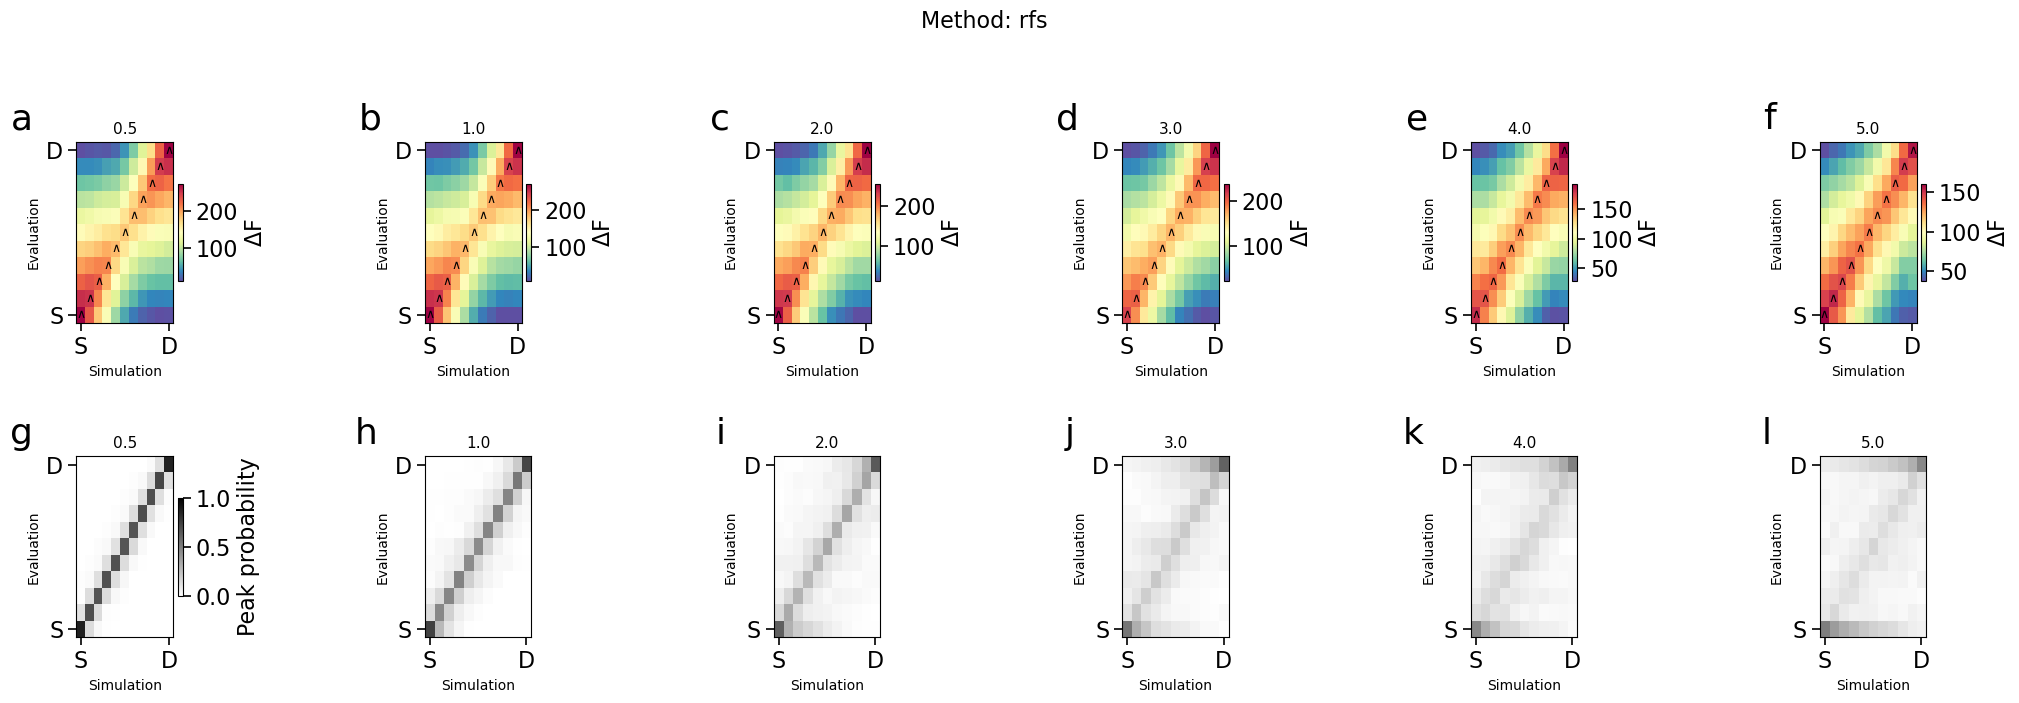

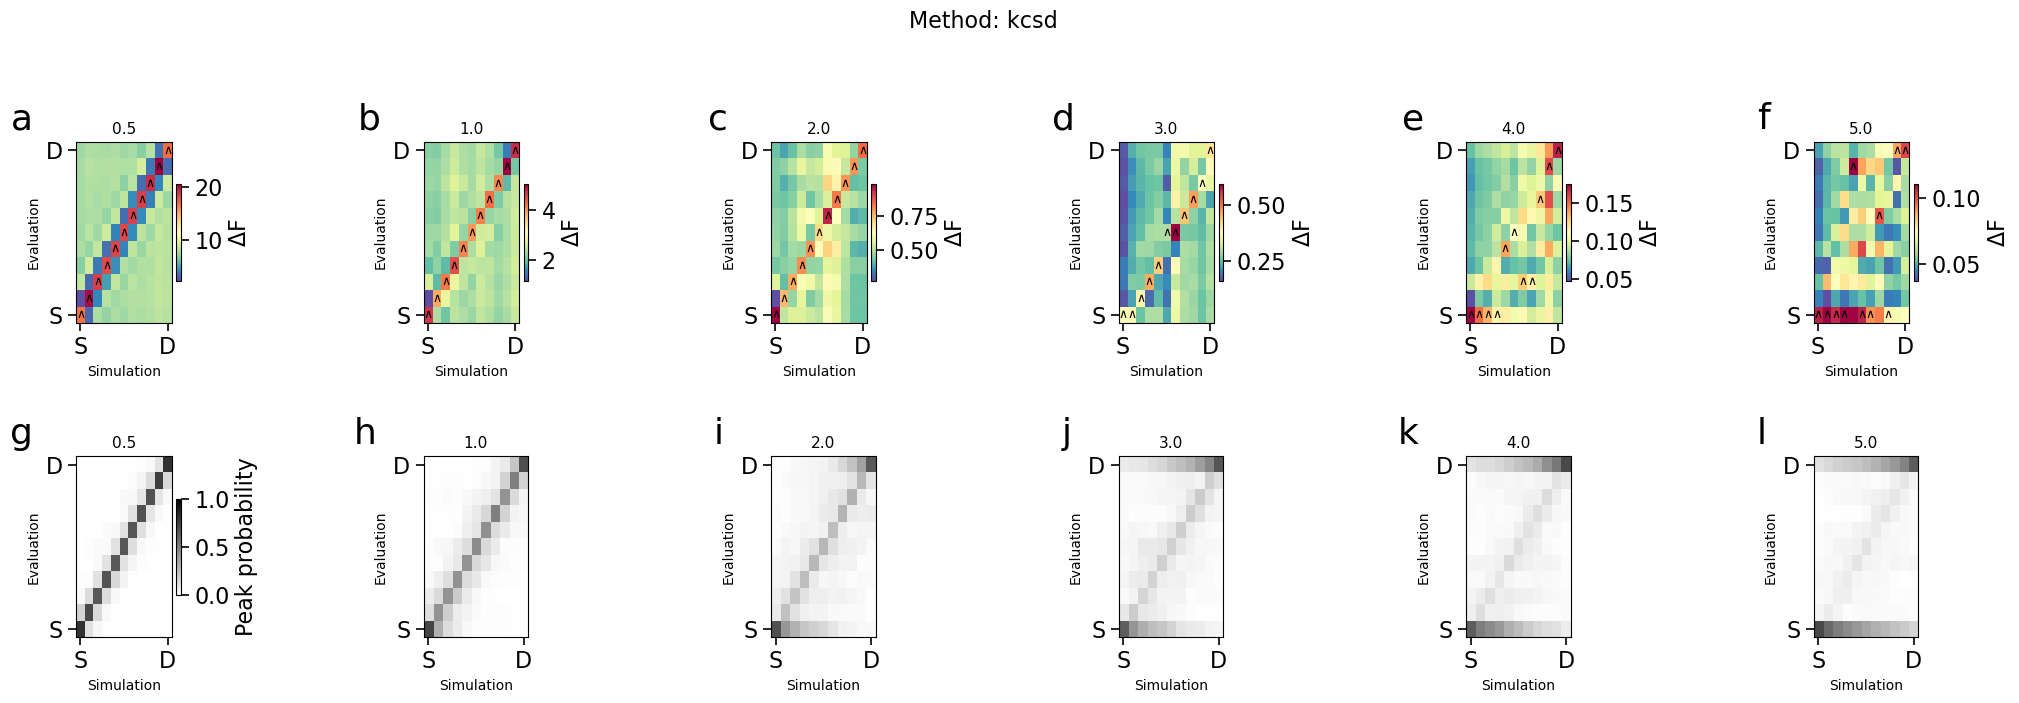

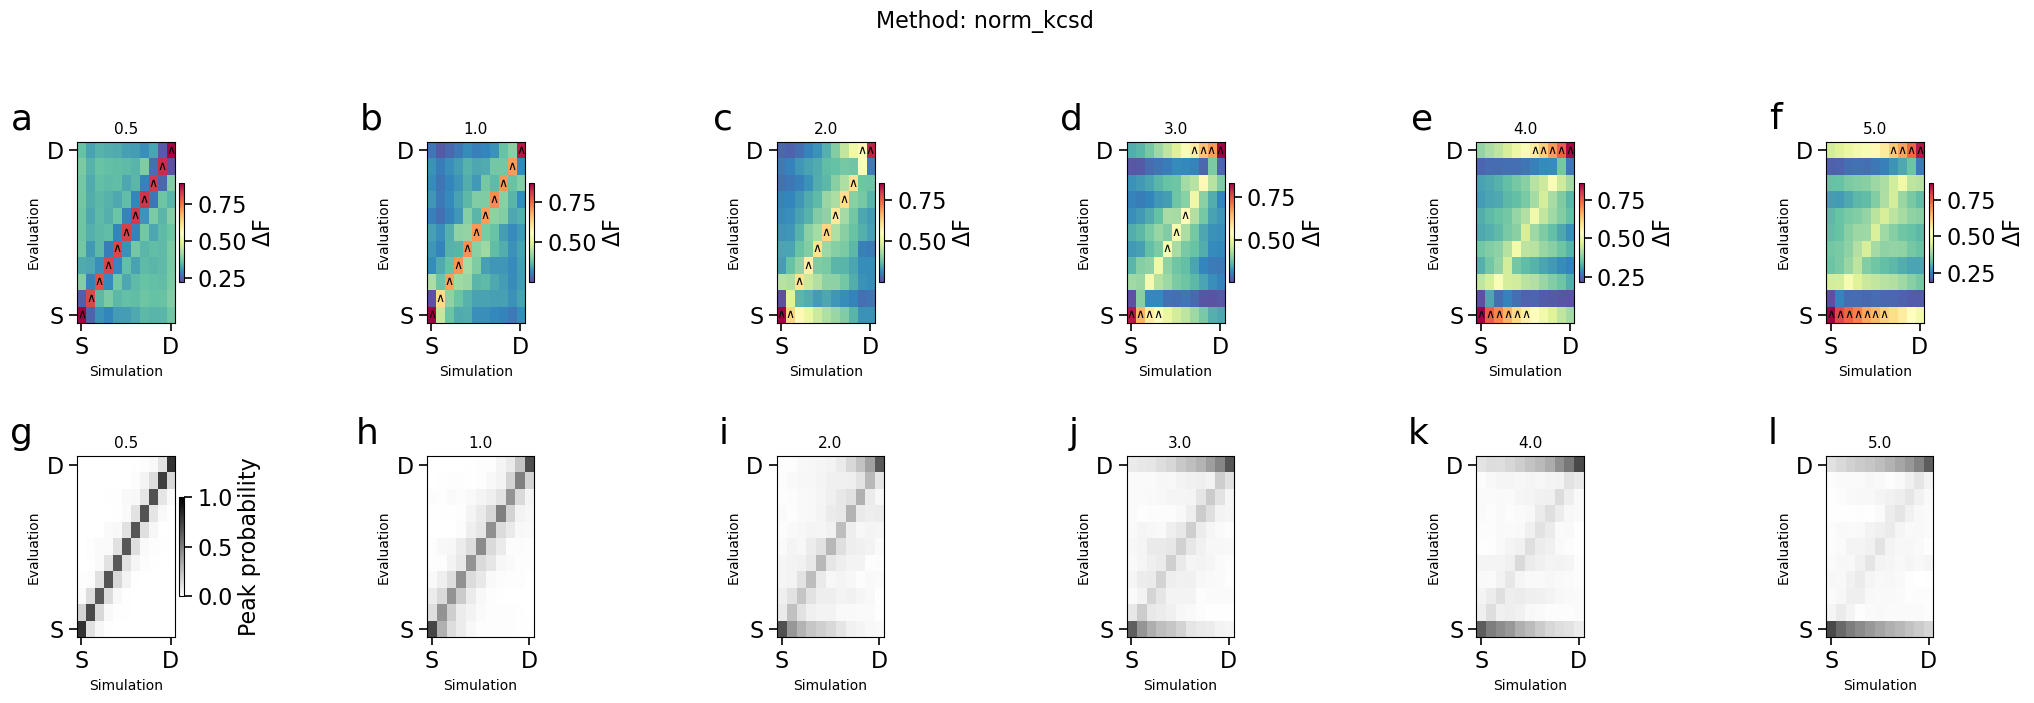

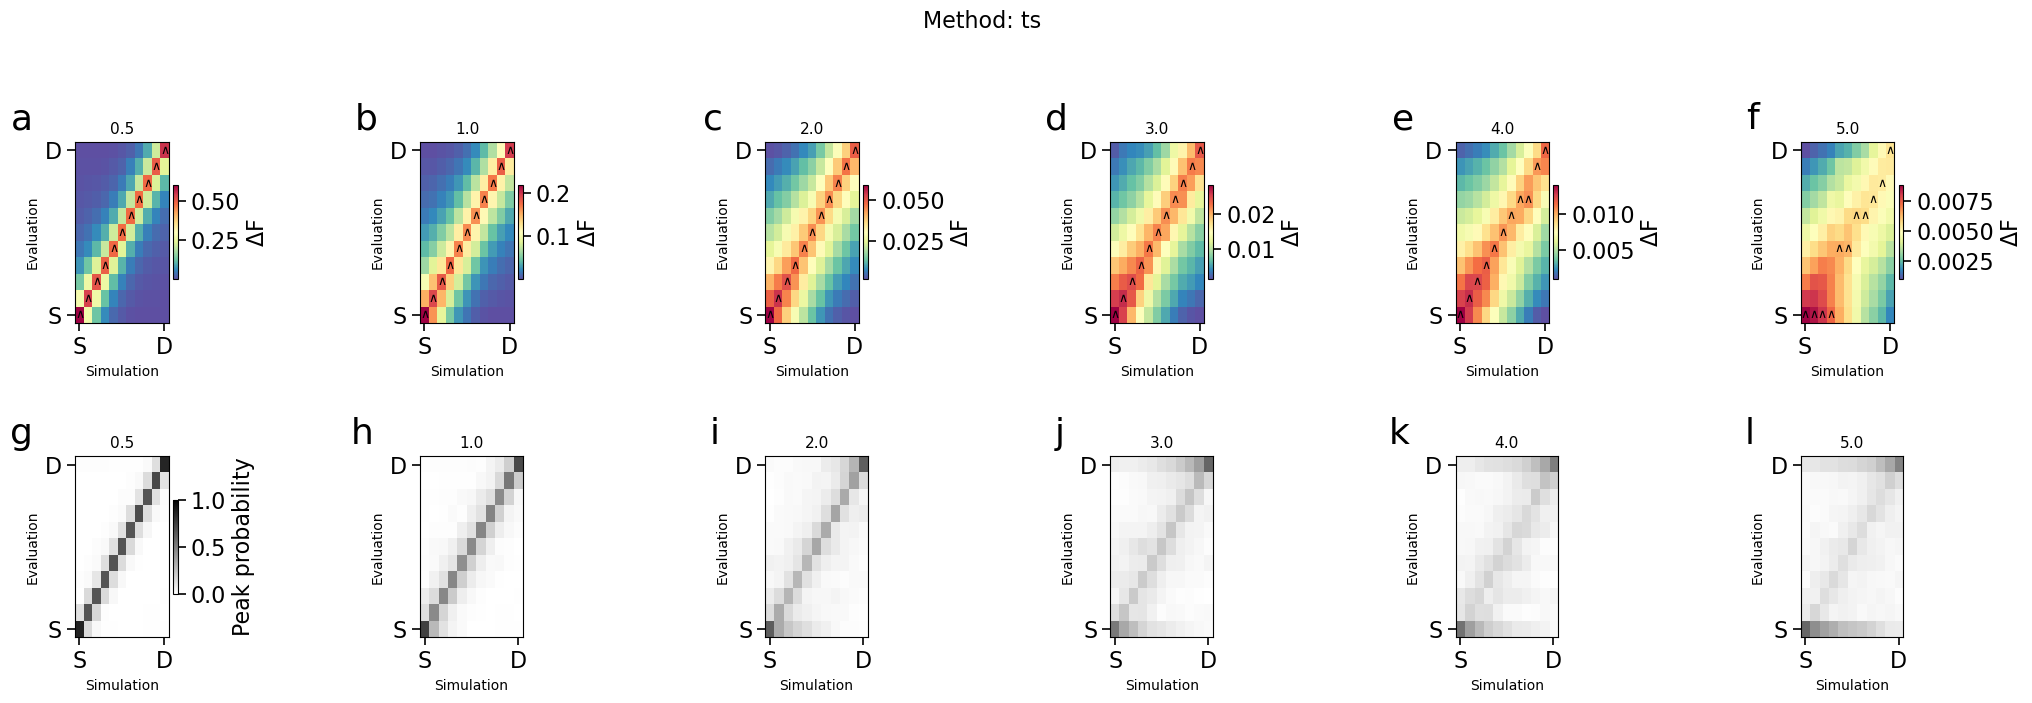

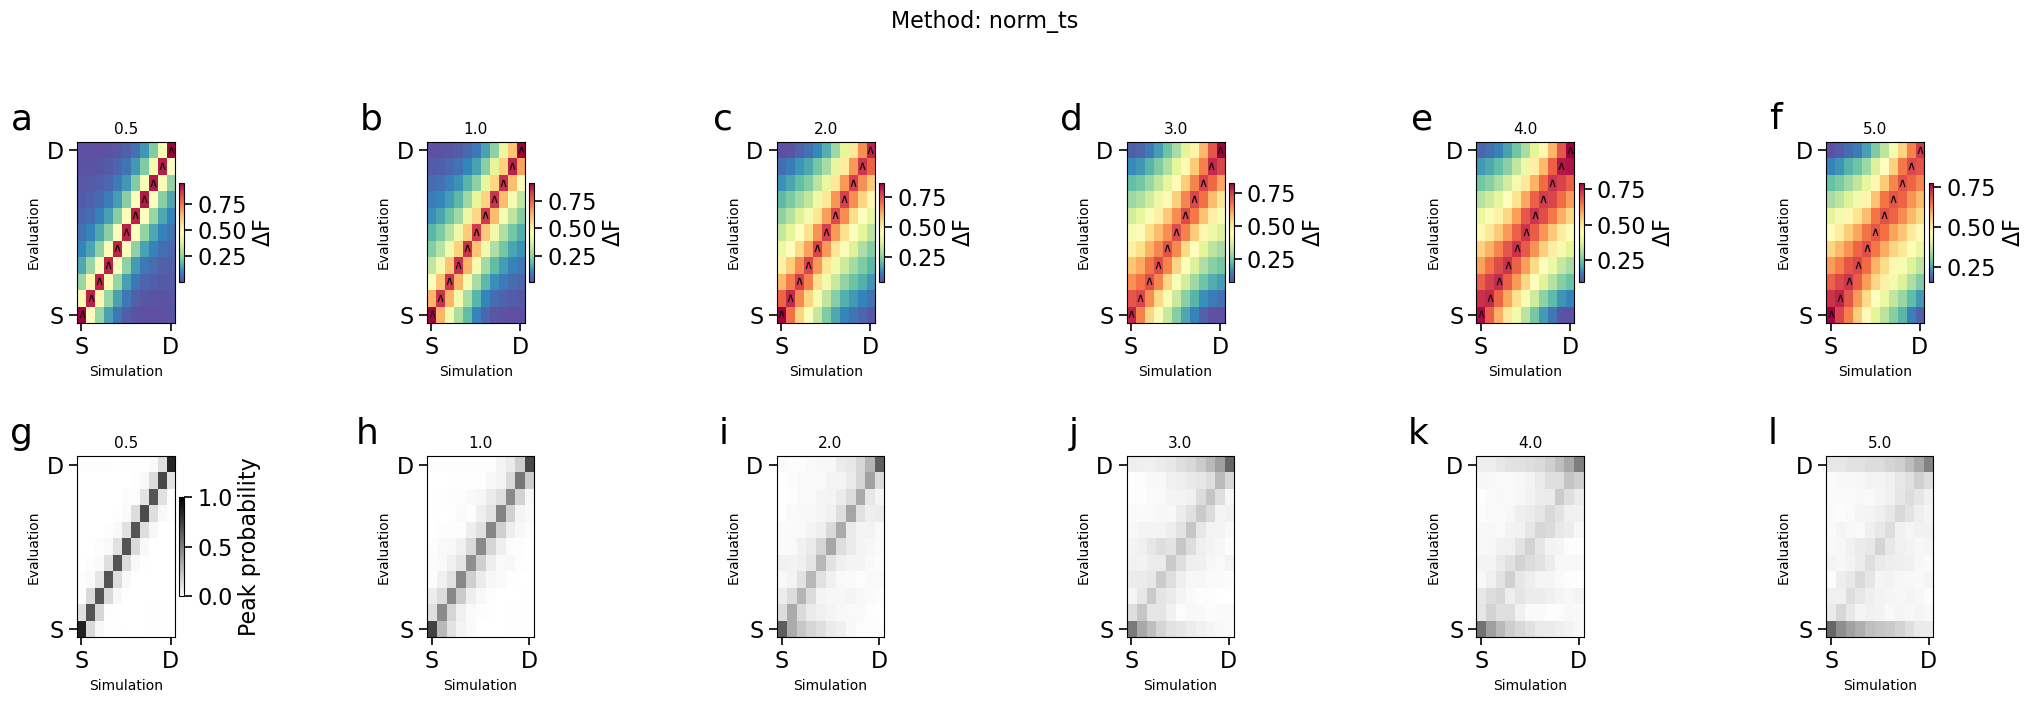

In [28]:
def annotate_peaks(ax, annot_obj):
    """Overlay markers at peak positions. annot_obj: (n_sim, n_eval) object array."""
    n_sim, n_eval = annot_obj.shape
    for sim_l in range(n_sim):
        for eval_l in range(n_eval):
            val = annot_obj[sim_l, eval_l]
            if val is not None:
                ax.text(sim_l, eval_l, val,
                        ha="center", va="center", fontsize=9, color="black",
                        fontweight="bold")
 
def setup_matrix_axes(ax, n_sim, n_eval):
    ax.set_xticks([0, n_sim - 1]);  ax.set_xticklabels(["S", "D"])
    ax.set_yticks([0, n_eval - 1]); ax.set_yticklabels(["S", "D"])
    ax.set_xlabel("Simulation", fontsize=10)
    ax.set_ylabel("Evaluation", fontsize=10)
 
for method in methods:
    n_err = len(err_levels_to_plot)
    plt.rcParams.update({"axes.spines.right": True, "axes.spines.top": True})
    fig, axes_grid = plt.subplots(2, n_err, figsize=(3.5 * n_err, 7), facecolor="white")
    if n_err == 1:
        axes_grid = axes_grid[:, np.newaxis]
    fig.suptitle(f"Method: {method}", fontsize=16, y=1.01)
    panel_row0 = list("abcdefghijklmnop")[:n_err]
    panel_row1 = list("abcdefghijklmnop")[n_err:2 * n_err]
 
    for err_idx, err in enumerate(err_levels_to_plot):
        key   = (method, err)
        m_mx  = np.mean(matrices_all[key], axis=0)      # (n_sim, n_eval)
        m_prob= np.mean(annots_bin[key],   axis=0)      # (n_sim, n_eval)
        n_sim, n_eval = m_mx.shape
        _, annot_obj, _ = find_peaks_col(m_mx, marker=r"$\wedge$")
        err_label = f"{err}"
 
        ax0 = axes_grid[0, err_idx]
        im0 = ax0.imshow(m_mx.T, cmap="Spectral_r", aspect="auto",
                         origin="lower", interpolation="nearest")
        annotate_peaks(ax0, annot_obj)
        setup_matrix_axes(ax0, n_sim, n_eval)
        ax0.set_title(err_label, fontsize=11)
        plt.colorbar(im0, ax=ax0, label=r"$\Delta$F", fraction=0.046, pad=0.04)
        add_subplot_label(ax0, panel_row0[err_idx], x=-0.45, y=1.22)
 
        ax1 = axes_grid[1, err_idx]
        im1 = ax1.imshow(m_prob.T, cmap="binary", aspect="auto",
                         origin="lower", interpolation="nearest", vmin=0, vmax=1)
        setup_matrix_axes(ax1, n_sim, n_eval)
        ax1.set_title(err_label, fontsize=11)
        if err_idx == 0:
            plt.colorbar(im1, ax=ax1, label="Peak probability", fraction=0.046, pad=0.04)
        add_subplot_label(ax1, panel_row1[err_idx], x=-0.45, y=1.22)
 
    plt.rcParams.update({"axes.spines.right": False, "axes.spines.top": False})
    plt.tight_layout()
    # plt.savefig(f"figure_matrices_{method}.png", bbox_inches="tight")
    # plt.close()
    # print(f"Matrix figure saved -> figure_matrices_{method}.png")

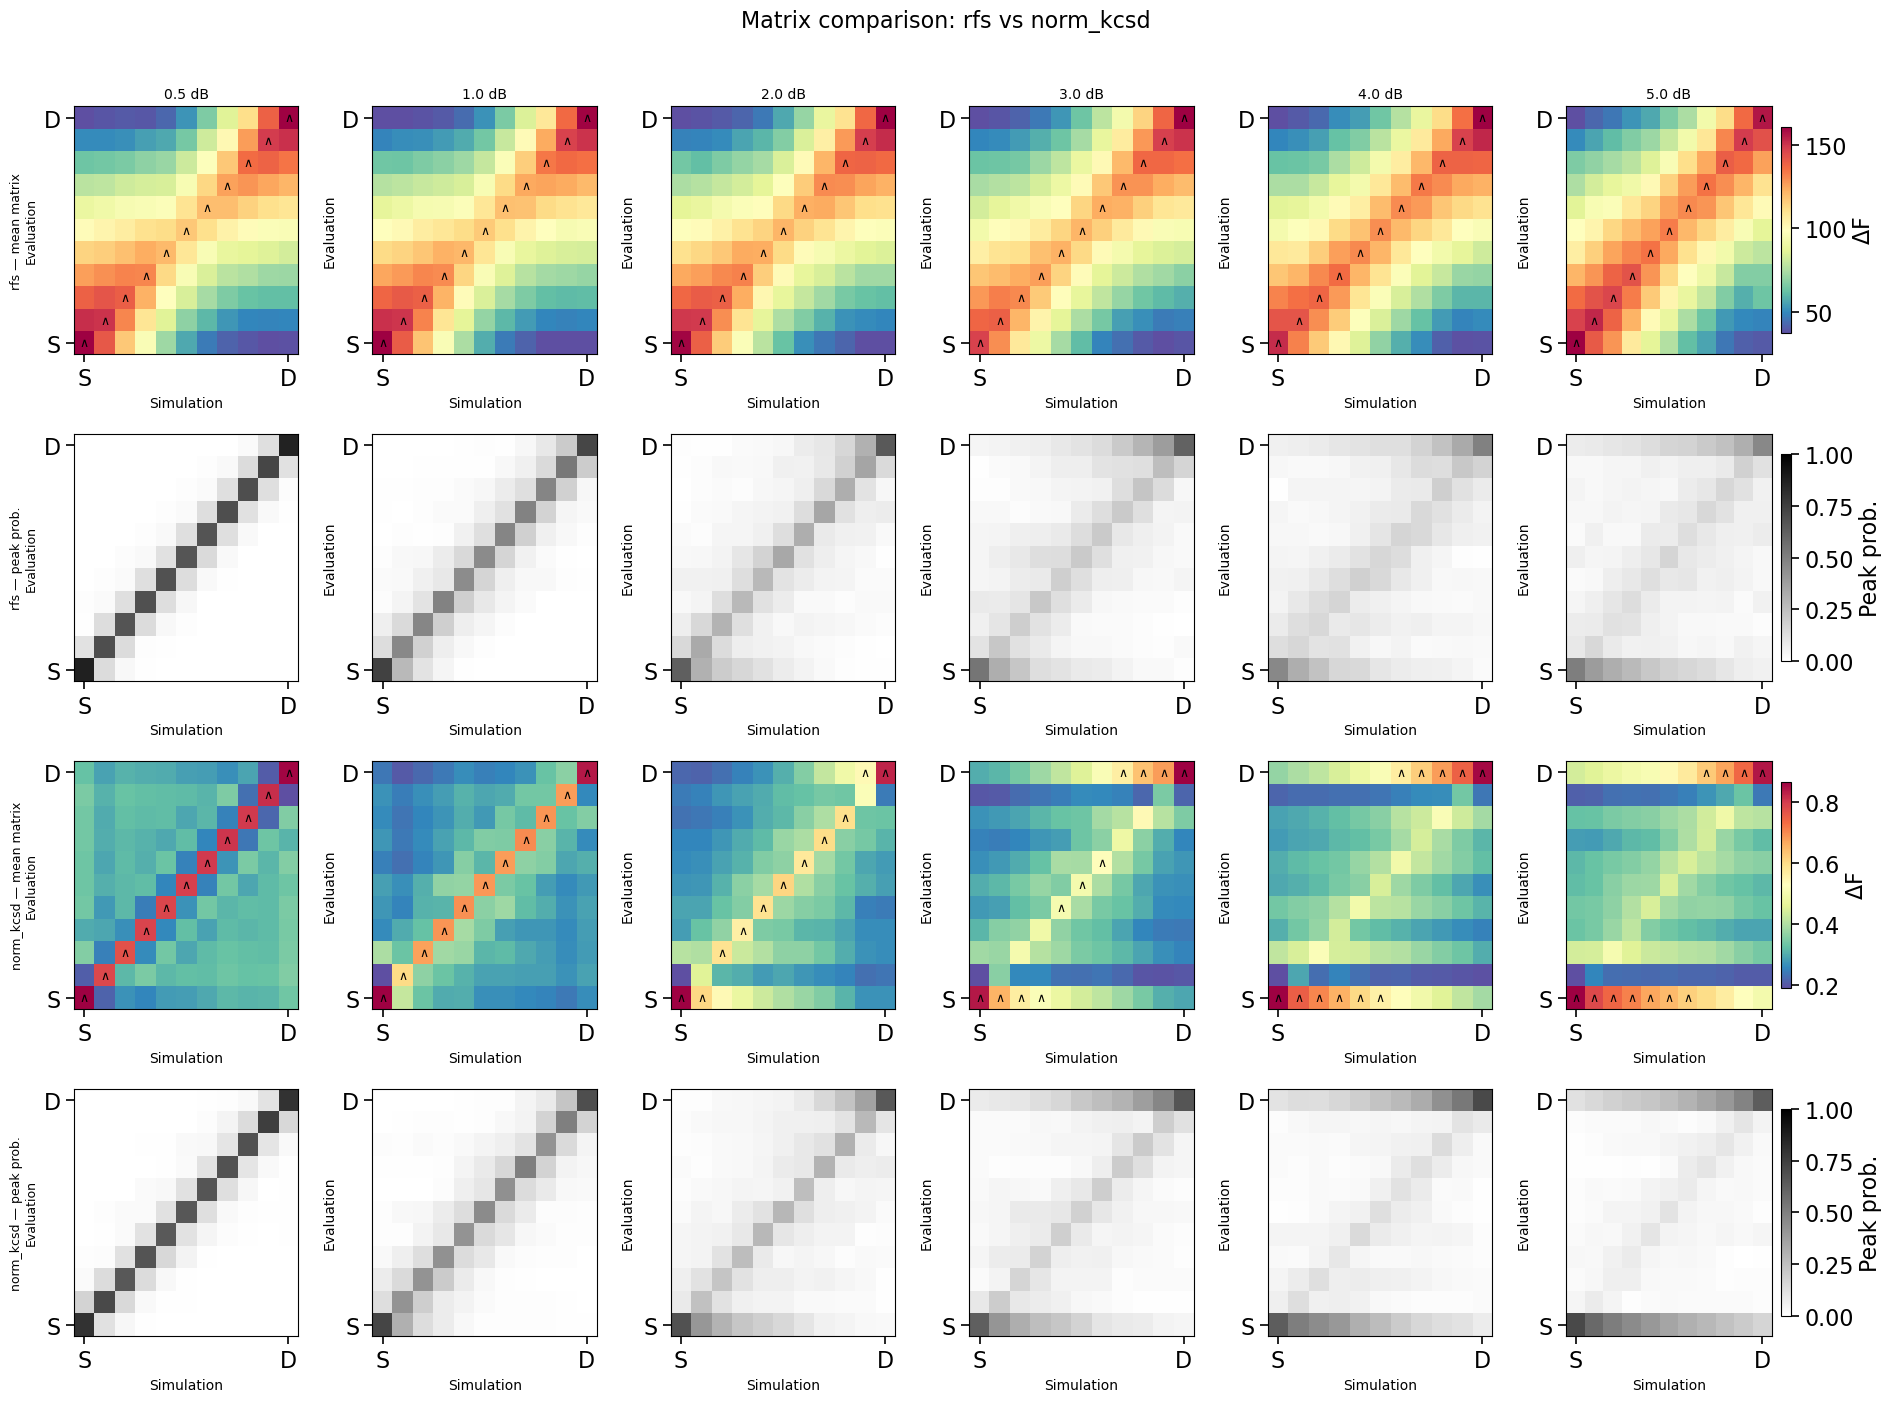

In [29]:

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1b — Side-by-side matrix comparison: rfs vs kcsd
# 4 rows (rfs-matrix, rfs-prob, kcsd-matrix, kcsd-prob) × n_err cols
# ─────────────────────────────────────────────────────────────────────────────
m_a = 'rfs'
m_b = 'norm_kcsd'

if m_a in methods and m_b in methods:
    n_err  = len(err_levels_to_plot)
    row_labels = [
        f"{m_a} — mean matrix",
        f"{m_a} — peak prob.",
        f"{m_b} — mean matrix",
        f"{m_b} — peak prob.",
    ]
    plt.rcParams.update({"axes.spines.right": True, "axes.spines.top": True})
    fig, axes_grid = plt.subplots(4, n_err, figsize=(3.2 * n_err, 14), facecolor="white")
    if n_err == 1:
        axes_grid = axes_grid[:, np.newaxis]
    fig.suptitle(f"Matrix comparison: {m_a} vs {m_b}", fontsize=16, y=1.005)
    panel_idx = 0
 
    for row_idx, (method_name, use_prob) in enumerate([
        (m_a, False), (m_a, True), (m_b, False), (m_b, True),
    ]):
        for err_idx, err in enumerate(err_levels_to_plot):
            key   = (method_name, err)
            m_mx  = np.mean(matrices_all[key], axis=0)
            m_prob= np.mean(annots_bin[key],   axis=0)
            n_sim, n_eval = m_mx.shape
            err_label = f"{err} dB"
            ax = axes_grid[row_idx, err_idx]
 
            if not use_prob:
                _, annot_obj, _ = find_peaks_col(m_mx, marker=r"$\wedge$")
                im = ax.imshow(m_mx.T, cmap="Spectral_r", aspect="auto",
                               origin="lower", interpolation="nearest")
                annotate_peaks(ax, annot_obj)
                if err_idx == n_err - 1:
                    plt.colorbar(im, ax=ax, label=r"$\Delta$F", fraction=0.046, pad=0.04)
            else:
                im = ax.imshow(m_prob.T, cmap="binary", aspect="auto",
                               origin="lower", interpolation="nearest", vmin=0, vmax=1)
                if err_idx == n_err - 1:
                    plt.colorbar(im, ax=ax, label="Peak prob.", fraction=0.046, pad=0.04)
 
            setup_matrix_axes(ax, n_sim, n_eval)
            if err_idx == 0:
                ax.set_ylabel(f"{row_labels[row_idx]}\nEvaluation", fontsize=9)
            if row_idx == 0:
                ax.set_title(err_label, fontsize=10)
            panel_idx += 1
 
    plt.rcParams.update({"axes.spines.right": False, "axes.spines.top": False})
    plt.tight_layout()
    # plt.savefig(f"figure_matrices_comparison_{m_a}_vs_{m_b}.png", bbox_inches="tight")
    # plt.close()
    # print(f"Side-by-side matrix figure saved -> figure_matrices_comparison_{m_a}_vs_{m_b}.png")

Figure 3: Diagonal dominance

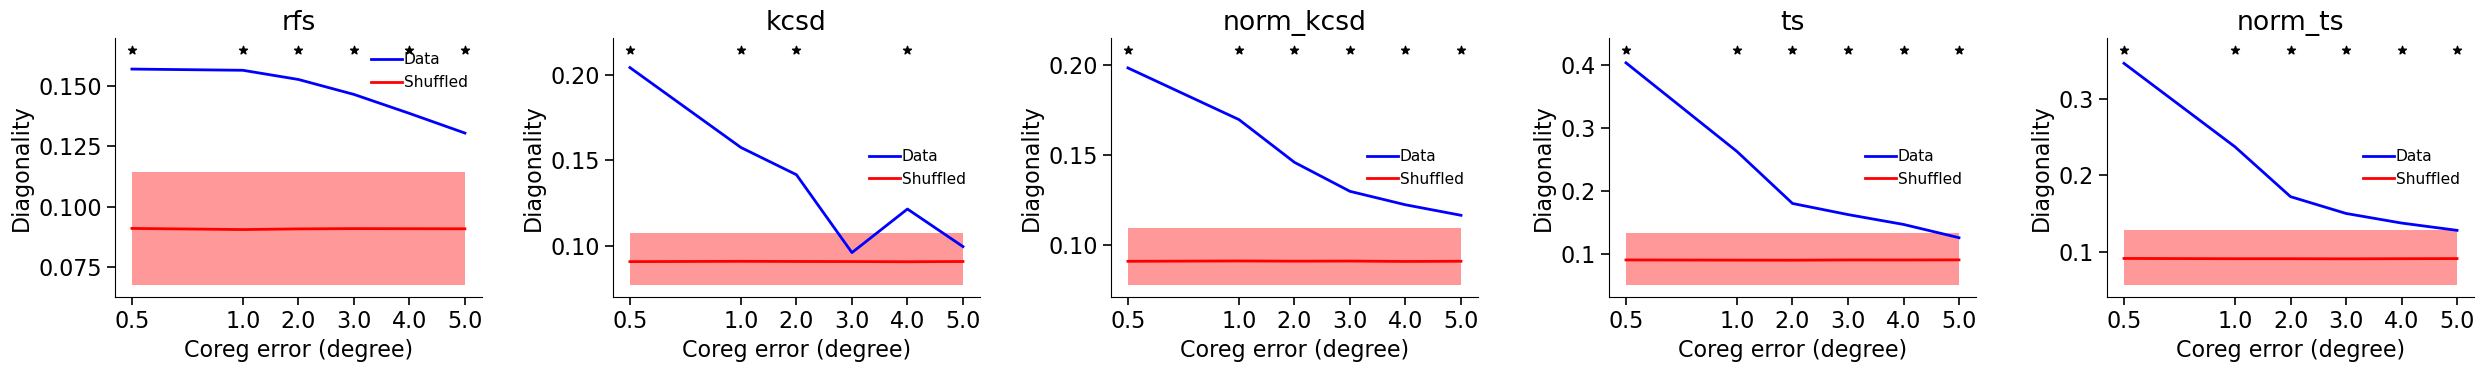

In [30]:
fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 4), facecolor='white')
if len(methods) == 1:
    axes = [axes]
 
for ax, method in zip(axes, methods):
    dds          = dds_all[method]
    permuted_dds = permuted_dds_all[method]
    p_vals       = p_vals_dds_all[method]
 
    dds_95ci_shuf = [np.percentile(permuted_dds, 2.5),
                     np.percentile(permuted_dds, 97.5)]
    sig_levels = np.where(p_vals < 0.05)[0]
 
    ax.plot(err_ix, dds,                              color='b',  lw=2, label='Data')
    ax.plot(err_ix, np.mean(permuted_dds, axis=-1),   color='r',  lw=2, label='Shuffled')
    ax.fill_between(err_ix, dds_95ci_shuf[0], dds_95ci_shuf[1],
                    color='r', lw=0, alpha=0.4)
    if len(sig_levels):
        ax.scatter(err_ix[sig_levels],
                   np.tile(dds.max() * 1.05, len(sig_levels)),
                   marker='*', color='k')
    ax.set_xticks(err_ix)
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel('Coreg error (degree)')
    ax.set_ylabel('Diagonality')
    ax.set_title(method)
    ax.legend(fontsize='x-small')
 
plt.tight_layout()
# plt.savefig('figure_S_diagonality_all_methods.png')
# plt.close()

Figure 4: Per-layer error & bias

All figures saved.


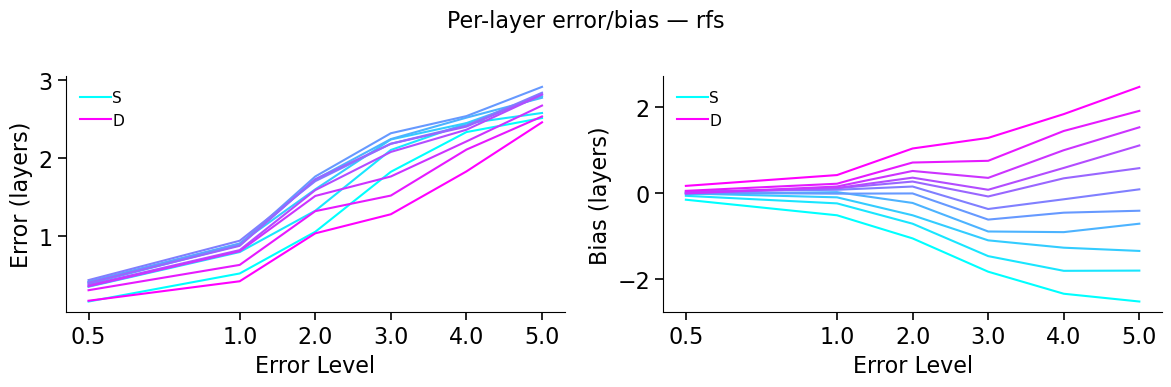

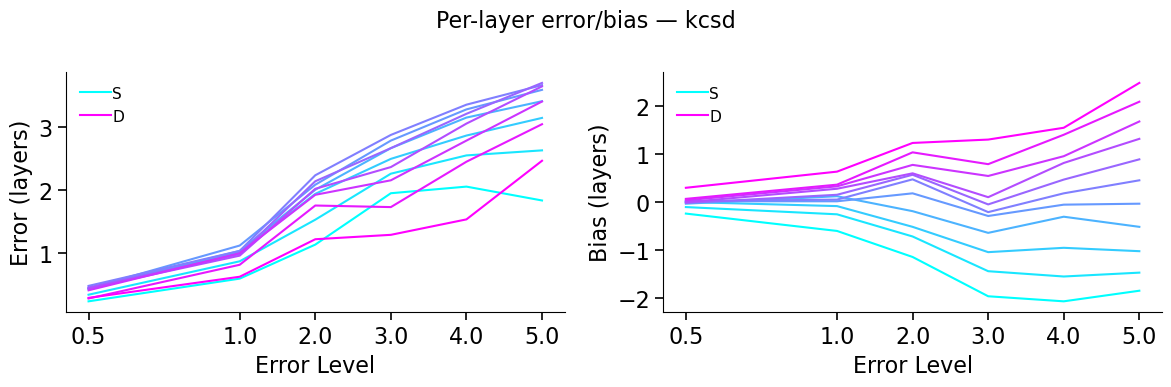

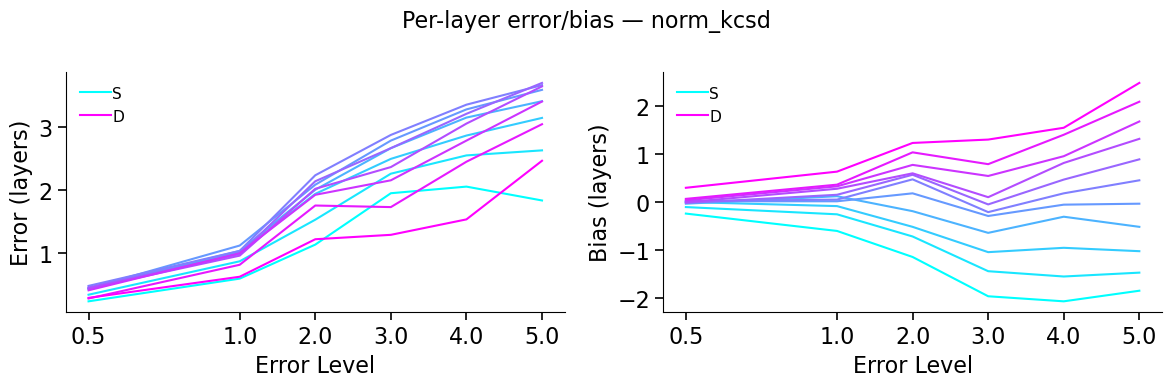

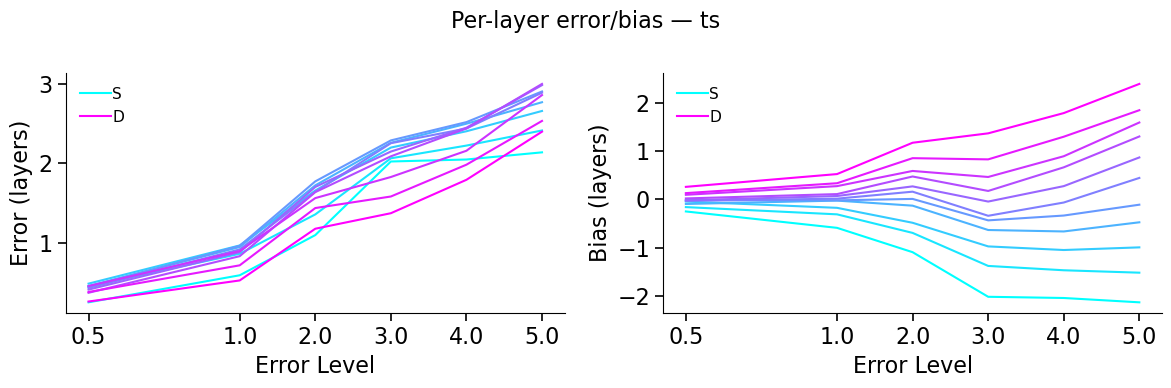

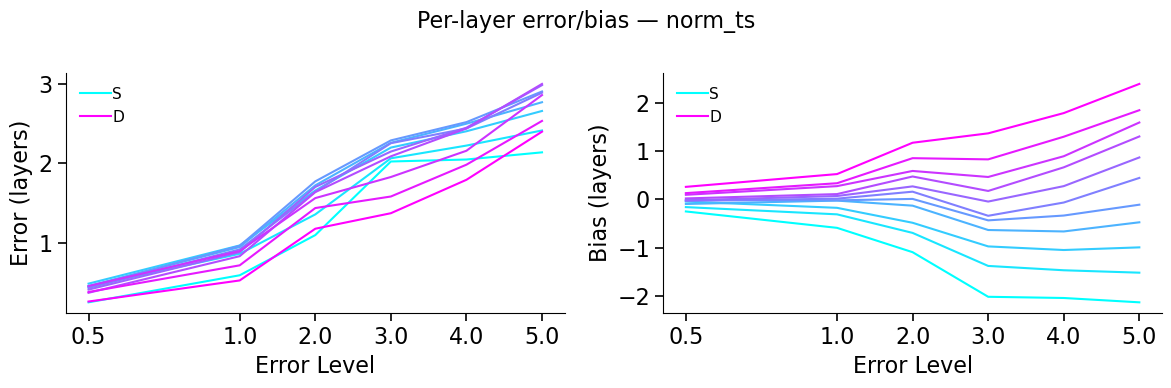

In [31]:
col_r = plt.cm.cool(np.linspace(0, 1, num=n_layers))
 
for method in methods:
    subset_all = res_df[res_df.method == method]
 
    # Build per-coreg-error arrays dynamically (avoids wrong n_vx assumption)
    all_layer_err_list  = []
    all_layer_bias_list = []
    for err in err_level_range:
        subset = subset_all[subset_all.err_level == err]
        all_layer_err_list.append(np.stack(subset['error'].tolist()))   # (n_vx, 11)
        all_layer_bias_list.append(np.stack(subset['bias'].tolist()))   # (n_vx, 11)
 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), facecolor='white')
    fig.suptitle(f'Per-layer error/bias — {method}', fontsize=16)
 
    # mean across vertices for each (err, layer) — list entries have shape (n_vx, 11)
    mean_err_per_err  = np.array([arr.mean(axis=0) for arr in all_layer_err_list])   # (n_err, 11)
    mean_bias_per_err = np.array([arr.mean(axis=0) for arr in all_layer_bias_list])  # (n_err, 11)
 
    for i in range(n_layers):
        lbl = 'S' if i == 0 else ('D' if i == n_layers - 1 else None)
        ax1.plot(err_ix, mean_err_per_err[:,  i], color=col_r[i], label=lbl)
        ax2.plot(err_ix, mean_bias_per_err[:, i], color=col_r[i], label=lbl)
 
    for ax, ylabel in zip([ax1, ax2], ['Error (layers)', 'Bias (layers)']):
        ax.set_xticks(err_ix)
        ax.set_xticklabels(tick_labels)
        ax.set_xlabel('Error Level')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize='x-small')
 
    plt.tight_layout()
    # plt.savefig(f'figure_S_layers_{method}.png')
    # plt.close()
 
print("All figures saved.")

### Rfs vs kcsd direct comparison 
For each coreg error level and each vertex we have a paired observation, error_rfs vs error_kcsd so we will test whether the difference is significantly different from 0 using permutation test on the paired difference 

Effect size: Cohen's d_z  = mean(diff) / std(diff)   (paired variant)

Same logic is applied to:
- error   (absolute, in layers)
- bias    (signed, in layers)
- diagonality score   (one value per coreg error level, not per vertex → bootstrap CI only, no per-vertex pairing)

In [32]:
COMPARE_METHODS = ('rfs', 'norm_kcsd')   # ← change here if you want a different pair
m_a, m_b = COMPARE_METHODS
n_perm_compare = 10_000
 
# ── helpers ──────────────────────────────────────────────────────────────────
 
def sign_flip_permutation_test(diff, n_perm=10_000):
    """
    One-sample permutation test: is mean(diff) significantly different from 0?
    Each permutation randomly flips the sign of each paired difference.
 
    Returns
    -------
    p_value   : two-tailed p-value
    effect_dz : Cohen's d_z  = mean(diff) / std(diff, ddof=1)
    perm_means: (n_perm,) null distribution of permuted means
    """
    observed = np.mean(diff)
    n = len(diff)
    perm_means = np.zeros(n_perm)
    for i in range(n_perm):
        signs = np.random.choice([-1, 1], size=n)
        perm_means[i] = np.mean(diff * signs)
    p_value = (np.sum(np.abs(perm_means) >= np.abs(observed)) + 1) / (n_perm + 1)
    effect_dz = observed / np.std(diff, ddof=1) if np.std(diff, ddof=1) > 0 else 0.0
    return p_value, effect_dz, perm_means
 
 
def bootstrap_ci(data, n_boot=5_000, ci=95):
    """Bootstrap 95 % CI of the mean."""
    boot_means = np.array([
        np.mean(data[np.random.choice(len(data), size=len(data))])
        for _ in range(n_boot)
    ])
    lo = (100 - ci) / 2
    return np.mean(data), np.percentile(boot_means, lo), np.percentile(boot_means, 100 - lo)

Per coreg error level paired comparison (error & bias)

In [33]:
comp_results = []   # list of dicts, one per coreg error
 
for err in err_level_range:
    sub_a = res_df[(res_df.method == m_a) & (res_df.err_level == err)].reset_index(drop=True)
    sub_b = res_df[(res_df.method == m_b) & (res_df.err_level == err)].reset_index(drop=True)
 
    # Align on vertex so the pairing is meaningful
    sub_a = sub_a.set_index('sim_vertex').sort_index()
    sub_b = sub_b.set_index('sim_vertex').sort_index()
    shared_vx = sub_a.index.intersection(sub_b.index)
    sub_a = sub_a.loc[shared_vx]
    sub_b = sub_b.loc[shared_vx]
 
    err_a = np.array(sub_a['error'].tolist()).mean(axis=1)   # (n_vx,)
    err_b = np.array(sub_b['error'].tolist()).mean(axis=1)
    bias_a = np.array(sub_a['bias'].tolist()).mean(axis=1)
    bias_b = np.array(sub_b['bias'].tolist()).mean(axis=1)
 
    diff_err  = err_a  - err_b     # positive → rfs worse than kcsd
    diff_bias = bias_a - bias_b
 
    p_err,  dz_err,  perm_err  = sign_flip_permutation_test(diff_err,  n_perm_compare)
    p_bias, dz_bias, perm_bias = sign_flip_permutation_test(diff_bias, n_perm_compare)
 
    _, err_ci_lo,  err_ci_hi  = bootstrap_ci(diff_err)
    _, bias_ci_lo, bias_ci_hi = bootstrap_ci(diff_bias)
 
    comp_results.append(dict(
        err_level=err,
        mean_err_a=err_a.mean(),   mean_err_b=err_b.mean(),
        mean_bias_a=bias_a.mean(), mean_bias_b=bias_b.mean(),
        diff_err_mean=diff_err.mean(),
        diff_err_ci=(err_ci_lo, err_ci_hi),
        diff_bias_mean=diff_bias.mean(),
        diff_bias_ci=(bias_ci_lo, bias_ci_hi),
        p_err=p_err,   dz_err=dz_err,   perm_err=perm_err,
        p_bias=p_bias, dz_bias=dz_bias, perm_bias=perm_bias,
        n_vx=len(shared_vx),
    ))
    print(f'[{m_a} vs {m_b}] {err:>5} degree | '
          f'Δerr={diff_err.mean():+.3f} (d_z={dz_err:+.2f}, p={p_err:.3f}) | '
          f'Δbias={diff_bias.mean():+.3f} (d_z={dz_bias:+.2f}, p={p_bias:.3f})')
 
comp_df = pd.DataFrame(comp_results)

[rfs vs norm_kcsd]   0.5 degree | Δerr=-0.055 (d_z=-0.24, p=0.000) | Δbias=-0.002 (d_z=-0.01, p=0.892)
[rfs vs norm_kcsd]   1.0 degree | Δerr=-0.151 (d_z=-0.41, p=0.000) | Δbias=-0.069 (d_z=-0.13, p=0.055)
[rfs vs norm_kcsd]   2.0 degree | Δerr=-0.340 (d_z=-0.59, p=0.000) | Δbias=-0.161 (d_z=-0.22, p=0.002)
[rfs vs norm_kcsd]   3.0 degree | Δerr=-0.327 (d_z=-0.45, p=0.000) | Δbias=-0.090 (d_z=-0.08, p=0.289)
[rfs vs norm_kcsd]   4.0 degree | Δerr=-0.433 (d_z=-0.47, p=0.000) | Δbias=-0.196 (d_z=-0.13, p=0.072)
[rfs vs norm_kcsd]   5.0 degree | Δerr=-0.447 (d_z=-0.40, p=0.000) | Δbias=-0.284 (d_z=-0.16, p=0.022)


diagonality comparison (one value per coreg error level, bootstrap CI on diff)

In [34]:
dds_a = dds_all[m_a]   # (n_err,)
dds_b = dds_all[m_b]
diff_dds = dds_a - dds_b
 
# Permutation null: shuffle assignment of (a,b) labels within each coreg error
# Since we only have one paired point per coreg error we use a sign-flip test across coreg errors
p_dds, dz_dds, perm_dds = sign_flip_permutation_test(diff_dds, n_perm_compare)
print(f'\n[{m_a} vs {m_b}] Diagonality | '
      f'mean Δ={diff_dds.mean():+.3f} (d_z={dz_dds:+.2f}, p={p_dds:.3f})')


[rfs vs norm_kcsd] Diagonality | mean Δ=+0.000 (d_z=+0.00, p=1.000)


Figure: rfs vs kcsd comparison 

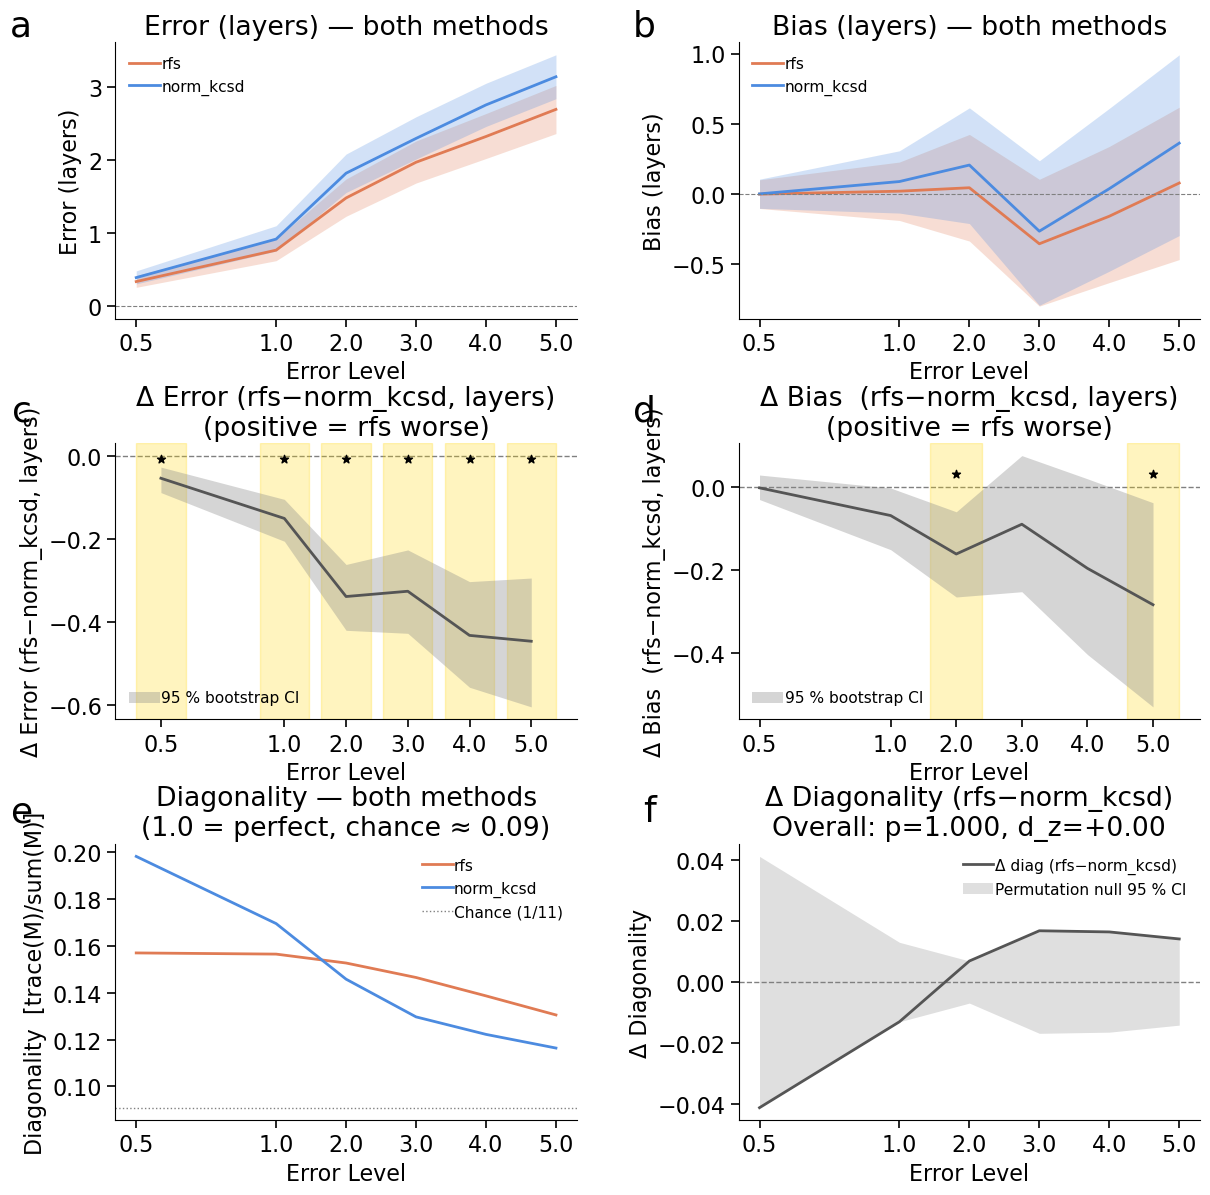

In [35]:
err_n = len(err_level_range)
diff_err_means  = np.array([r['diff_err_mean']  for r in comp_results])
diff_bias_means = np.array([r['diff_bias_mean'] for r in comp_results])
diff_err_lo  = np.array([r['diff_err_ci'][0]  for r in comp_results])
diff_err_hi  = np.array([r['diff_err_ci'][1]  for r in comp_results])
diff_bias_lo = np.array([r['diff_bias_ci'][0] for r in comp_results])
diff_bias_hi = np.array([r['diff_bias_ci'][1] for r in comp_results])
p_errs  = np.array([r['p_err']  for r in comp_results])
p_biases = np.array([r['p_bias'] for r in comp_results])
 
COLOR = {m_a: '#E07B54', m_b: '#4C8BE0'}   # distinct warm/cool pair
ALPHA_CI = 0.25
 
fig = plt.figure(figsize=(14, 14), facecolor='white')
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── row 0: absolute errors per method ────────────────────────────────────────
for col_idx, (metric, ylabel) in enumerate([('error', 'Error (layers)'),
                                             ('bias',  'Bias (layers)')]):
    ax = fig.add_subplot(gs[0, col_idx])
    for mname, color in COLOR.items():
        s = stats[mname]
        key_res  = f'{metric}_res'
        key_shuf = f'shuf_{metric}_res'
        ax.plot(err_ix, s[key_res][:, 0], color=color, lw=2, label=mname)
        ax.fill_between(err_ix, s[key_res][:, 1], s[key_res][:, 2],
                        color=color, alpha=ALPHA_CI, lw=0)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_xticks(err_ix);  ax.set_xticklabels(tick_labels)
    ax.set_xlabel('Error Level');  ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} — both methods')
    ax.legend(fontsize='x-small')
    panel_label = 'a' if col_idx == 0 else 'b'
    add_subplot_label(ax, panel_label, x=-0.18, y=1.12)
 
# ── row 1: Δ metric = rfs − kcsd ─────────────────────────────────────────────
for col_idx, (diff_m, diff_lo, diff_hi, p_arr, ylabel, panel) in enumerate([
    (diff_err_means,  diff_err_lo,  diff_err_hi,  p_errs,   f'Δ Error ({m_a}−{m_b}, layers)', 'c'),
    (diff_bias_means, diff_bias_lo, diff_bias_hi, p_biases, f'Δ Bias  ({m_a}−{m_b}, layers)', 'd'),
]):
    ax = fig.add_subplot(gs[1, col_idx])
    ax.axhline(0, color='grey', lw=1.0, ls='--', zorder=0)
    ax.plot(err_ix, diff_m, color='#555555', lw=2)
    ax.fill_between(err_ix, diff_lo, diff_hi, color='#888888', alpha=0.35, lw=0,
                    label='95 % bootstrap CI')
 
    # Shade regions where the null distribution overlaps zero (non-significant)
    sig_mask = p_arr < 0.05
    for ix_s, (x_val, is_sig) in enumerate(zip(err_ix, sig_mask)):
        if is_sig:
            ax.axvspan(x_val - 0.4, x_val + 0.4, color='gold', alpha=0.25, zorder=0)
 
    # Stars above/below
    sig_ix_arr = np.where(sig_mask)[0]
    if len(sig_ix_arr):
        y_star = diff_m.max() + (diff_m.max() - diff_m.min()) * 0.12
        ax.scatter(err_ix[sig_ix_arr], np.tile(y_star, len(sig_ix_arr)),
                   marker='*', color='k', zorder=5)
 
    ax.set_xticks(err_ix);  ax.set_xticklabels(tick_labels)
    ax.set_xlabel('Error Level');  ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}\n(positive = {m_a} worse)')
    ax.legend(fontsize='x-small')
    add_subplot_label(ax, panel, x=-0.18, y=1.18)
 
# ── row 2 left: diagonality both methods ─────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
for mname, color in COLOR.items():
    dds_vals     = dds_all[mname]
    perm_vals    = permuted_dds_all[mname]
    ci_lo = np.percentile(perm_vals, 2.5,  axis=1)   # per-err null CI
    ci_hi = np.percentile(perm_vals, 97.5, axis=1)
    ax.plot(err_ix, dds_vals, color=color, lw=2, label=mname)
 
# Add chance level annotation
chance = 1.0 / n_layers
ax.axhline(chance, color='grey', lw=1.0, ls=':', label=f'Chance (1/{n_layers})')
ax.set_xticks(err_ix);  ax.set_xticklabels(tick_labels)
ax.set_xlabel('Error Level');  ax.set_ylabel('Diagonality  [trace(M)/sum(M)]')
ax.set_title('Diagonality — both methods\n'
             '(1.0 = perfect, chance ≈ {:.2f})'.format(chance))
ax.legend(fontsize='x-small')
add_subplot_label(ax, 'e', x=-0.18, y=1.18)
 
# ── row 2 right: Δ diagonality with permutation null ─────────────────────────
ax = fig.add_subplot(gs[2, 1])
ax.axhline(0, color='grey', lw=1.0, ls='--', zorder=0)
ax.plot(err_ix, diff_dds, color='#555555', lw=2, label=f'Δ diag ({m_a}−{m_b})')
 
# Null distribution envelope (from the sign-flip permutation across coreg errors)
# Build per-err null by doing sign-flip of diff_dds
perm_diff_dds = np.zeros((n_perm_compare, err_n))
for i in range(n_perm_compare):
    signs = np.random.choice([-1, 1], size=err_n)
    perm_diff_dds[i] = diff_dds * signs
null_lo = np.percentile(perm_diff_dds, 2.5,  axis=0)
null_hi = np.percentile(perm_diff_dds, 97.5, axis=0)
ax.fill_between(err_ix, null_lo, null_hi, color='grey', alpha=0.25, lw=0,
                label='Permutation null 95 % CI')
 
# Overall significance marker in title
sig_str = f'p={p_dds:.3f}, d_z={dz_dds:+.2f}'
ax.set_title(f'Δ Diagonality ({m_a}−{m_b})\nOverall: {sig_str}')
ax.set_xticks(err_ix);  ax.set_xticklabels(tick_labels)
ax.set_xlabel('Error Level');  ax.set_ylabel(f'Δ Diagonality')
ax.legend(fontsize='x-small')
add_subplot_label(ax, 'f', x=-0.18, y=1.18)
 
# plt.savefig(f'figure_comparison_{m_a}_vs_{m_b}.png', bbox_inches='tight')
# plt.close()
# print(f"Comparison figure saved → figure_comparison_{m_a}_vs_{m_b}.png")